In [ ]:
# моделирование движения
# нерелятивистского электрического заряда
# в поле магнитного диполя

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение метода solve_ivp из библиотеки scipy.integrate
from scipy.integrate import solve_ivp

# подключение библиотеки matplotlib
import matplotlib.pyplot as plt

# подключение функции fft, возвращающей
# коэффициенты дискретного преобразования Фурье, и
# функции fftfreq, возвращающей частоты спектральных гармоник
from scipy.fft import fft, fftfreq


In [2]:
# Ячейка № 2

# задание массива, используемого для
# размещения безразмерных координат
# магнитного момента диполя
M = np.array([0, np.sin(11.5 * np.pi / 180), np.cos(11.5 * np.pi / 180)])


# задание функции, возвращающей значения
# координат вектора-функции,
# стоящей в левой части системы (6.84)
def Force(t, z):
    # копирование координат радиуса-вектора в массив R
    R = np.array([z[0], z[2], z[4]])

    # вычисление значения скалярного произведения
    # магнитного момента диполя на радиус-вектор
    # электрического заряда
    dot_MR = np.dot(M, R)

    # вычисление длины радиуса-вектора электрического заряда
    mod_R = np.sqrt(R[0] ** 2 + R[1] ** 2 + R[2] ** 2)

    # вычисление значений напряженностей магнитного поля диполя
    # в точке нахождения электрического заряда
    Hx = (3 * dot_MR * R[0]) / mod_R**5 - M[0] / mod_R**3
    Hy = (3 * dot_MR * R[1]) / mod_R**5 - M[1] / mod_R**3
    Hz = (3 * dot_MR * R[2]) / mod_R**5 - M[2] / mod_R**3

    # инициализация массива F
    F = np.zeros(6)

    # вычисление координат вектора-функции,
    # стоящей в правой части (6.87)
    F[0] = z[1]
    F[1] = 2 * np.pi * (Hz * z[3] - Hy * z[5])
    F[2] = z[3]
    F[3] = 2 * np.pi * (Hx * z[5] - Hz * z[1])
    F[4] = z[5]
    F[5] = 2 * np.pi * (Hy * z[1] - Hx * z[3])

    return F

In [3]:
# Ячейка № 3

# задание начальных условий СДУ (6.87):

# задание значения абсциссы
# радиуса-вектора в момент времени t = 0
x0 = 1.0

# задание значения ординаты
# радиуса-вектора в момент времени t = 0
y0 = 0.0

# задание значения ординаты
# радиуса-вектора в момент времени t = 0
z0 = 0.0

# задание значения проекции
# скорости заряда
# на ось OX  в момент времени t = 0
vx0 = 0.1

# задание значения проекции
# скорости заряда
# на ось OY  в момент времени t = 0
vy0 = 0.1
# задание значения проекции
# скорости заряда
# на ось OZ  в момент времени t = 0
vz0 = 0.01

# задание максимального значения
# шага интегрирования СДУ (6.87)
dt = 2 * 10**-2

# задание длительности временного интервала,
# на котором вычисляется численное решение СДУ (6.87)
Tmax = 40000

# вычисление численного решения СДУ (6.87)
Solv = solve_ivp(Force, [0, Tmax], [x0, vx0, y0, vy0, z0, vz0], max_step=dt)

# определение числа узлов
# временной сетки, используемой
# для вычисления численного решения
# СДУ (6.87)
N = len(Solv.t)

# инициализация массива mod_R, используемого
# для хранения значений модуля радиуса-вектора
mod_R = np.zeros(N)

# инициализация массива mod_Rxy, используемого
# для хранения мгновенных значений
# модуля проекции радиуса-вектора
# электрического заряда на плоскость XOY
mod_Rxy = np.zeros(N)

# вычисление мгновенных значений
# модуля радиуса-вектора
# электрического заряда
mod_R[:] = np.sqrt(Solv.y[0, :] ** 2 + Solv.y[2, :] ** 2 + Solv.y[4, :] ** 2)

# вычисление мгновенных значений
# модуля проекции радиуса-вектора
# электрического заряда
# на плоскость XOY
mod_Rxy[:] = np.sqrt(Solv.y[0, :] ** 2 + Solv.y[2, :] ** 2)


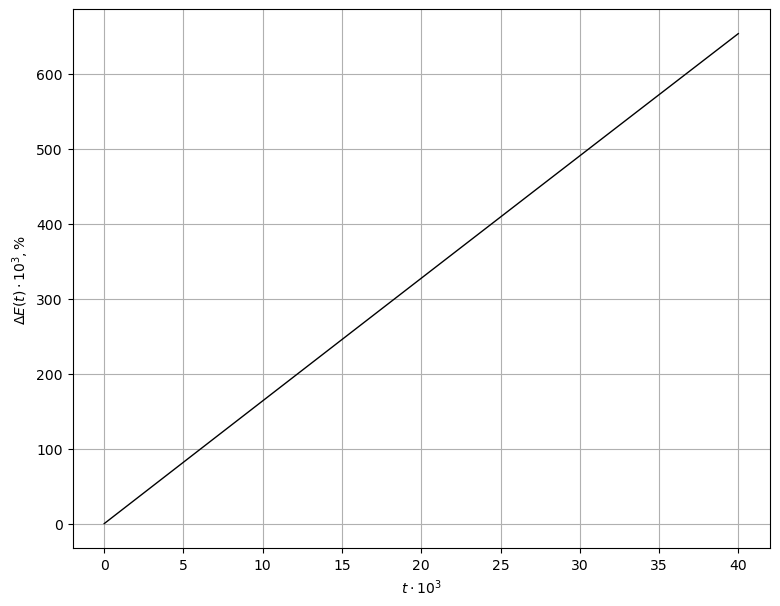

In [ ]:
# Ячейка № 4

# вычисление и визуализации зависимости
# погрешности сохранения кинетической энергии
# электрического заряда от времени

# определяем число узлов временной сетки,
# в которых вычислены численные решения СДУ (6.87)
N = len(Solv.t)
# инициализация массива dE
dE = np.zeros(N)
# вычисление начального значения энергии
E0 = Solv.y[1, 0] ** 2 + Solv.y[3, 0] ** 2 + Solv.y[5, 0] ** 2

# вычисление мгновенных значений
# относительной погрешности выполнения
# закона сохранения энергии (dE(:))
dE[:] = (
    np.abs(Solv.y[1, :] ** 2 + Solv.y[3, :] ** 2 + Solv.y[5, :] ** 2 - E0) / E0 * 100
)

# визуализация звисимости dE(:)
plt.figure(figsize=(9, 7))
plt.plot(Solv.t / 10**3, dE * 10**3, "-k", lw=1)
plt.xlabel(r"$t \cdot 10^3$", fontsize=10)
plt.ylabel(r"$\Delta E(t) \cdot 10^{3}, \%$", fontsize=10)
plt.grid(True)

plt.show()

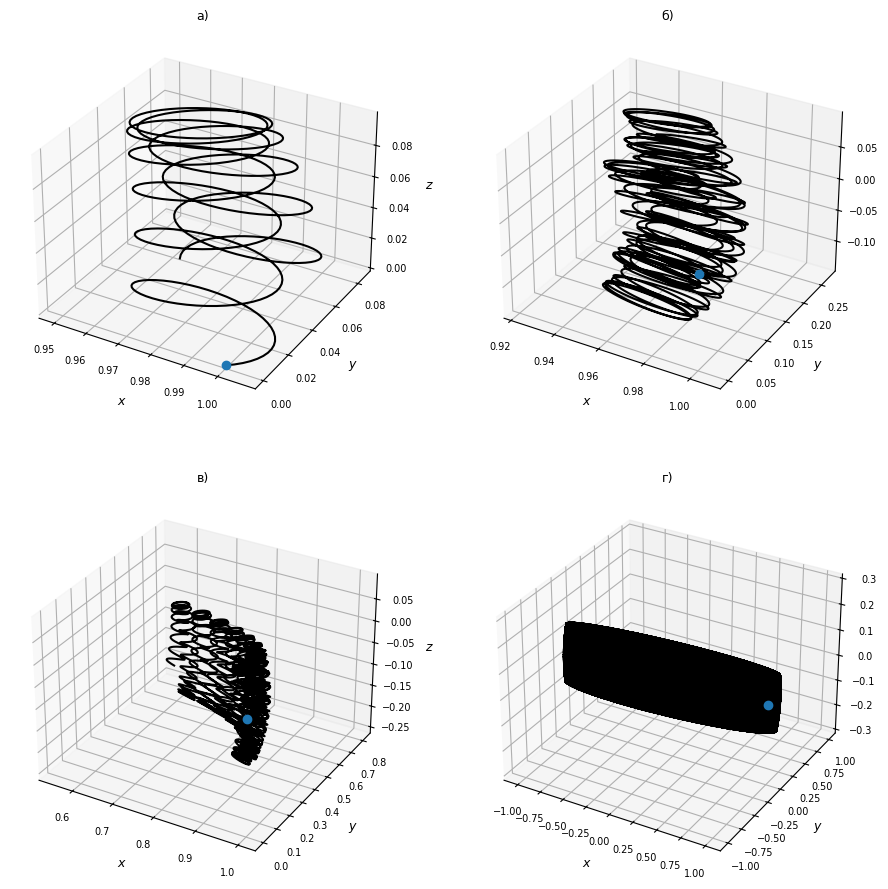

In [5]:
# Ячейка № 5

# 3D-визуализация траекторий движения
# электрического заряда
# в магнитном поле диполя
# на выбранных временных интервалах

# визуализация траектории электрического заряда
# в магнитном поле диполя
# на временном интервале [0,40]
fig = plt.figure(figsize=(11, 11))

ax = fig.add_subplot(2, 2, 1, projection="3d")
ax.set_box_aspect(None, zoom=1.0)
# задание размера шрифта подписей делений
# используемых координатных сеток
ax.tick_params(labelsize=7)

# задание значений границ временных интервалов,
# на которых визуализируются траектории
# движения электрического заряда и
# зависимости его координат от времени
T1_fin = 10
N1_fin = round(T1_fin / dt)

T2_fin = 50
N2_fin = round(T2_fin / dt)

T3_fin = 200
N3_fin = round(T3_fin / dt)

plt.plot(Solv.y[0, 0:N1_fin], Solv.y[2, 0:N1_fin], Solv.y[4, 0:N1_fin], "black")

# визуализация начального положения электрического заряда
ax.plot3D(Solv.y[0, 0], Solv.y[2, 0], Solv.y[4, 0], "o")
ax.set_title("а)", fontsize=9)

# отображение обозначений координатных осей
ax.set_xlabel(r"$x$", fontsize=9)
ax.set_ylabel(r"$y$", fontsize=9)
ax.set_zlabel(r"$z$", fontsize=9)

# визуализация траектории движения
# электрического заряда
# в магнитном поле диполя
# на временном интервале [0,200]
ax = fig.add_subplot(2, 2, 2, projection="3d")
ax.set_box_aspect(None, zoom=1.0)

# визуализация траектории движения электрического заряда
ax.plot3D(Solv.y[0, 0:N2_fin], Solv.y[2, 0:N2_fin], Solv.y[4, 0:N2_fin], "black")

# визуализация начального положения электрического заряда
ax.plot3D(Solv.y[0, 0], Solv.y[2, 0], Solv.y[4, 0], "o")
ax.set_title("б)", fontsize=9)

# задание размера шрифта подписей делений
# используемых координатных сеток
ax.tick_params(labelsize=7)

# отображение обозначений координатных осей
ax.set_xlabel(r"$x$", fontsize=9)
ax.set_ylabel(r"$y$", fontsize=9)
ax.set_zlabel(r"$z$", fontsize=9)

# визуализация траектории движения электрического заряда
# в магнитном поле диполя
# на временном интервале [0,400]
ax = fig.add_subplot(2, 2, 3, projection="3d")
ax.set_box_aspect(None, zoom=1.0)

# визуализация траектории движения электрического заряда
ax.plot3D(Solv.y[0, 0:N3_fin], Solv.y[2, 0:N3_fin], Solv.y[4, 0:N3_fin], "black")

# визуализация начального положения электрического заряда
ax.plot3D(Solv.y[0, 0], Solv.y[2, 0], Solv.y[4, 0], "o")
ax.set_title("в)", fontsize=9)

# задание размера шрифта подписей делений
# используемых координатных сеток
ax.tick_params(labelsize=7)


ax.set_xlabel(r"$x$", fontsize=9)
ax.set_ylabel(r"$y$", fontsize=9)
ax.set_zlabel(r"$z$", fontsize=9)

# визуализация траектории движения электрического заряда
# в магнитном поле диполя
# на временном интервале [0, 4 * 10^4]
ax = fig.add_subplot(2, 2, 4, projection="3d")
ax.set_box_aspect(None, zoom=1.0)

# визуализация траектории движения электрического заряда
ax.plot3D(Solv.y[0, :], Solv.y[2, :], Solv.y[4, :], "black")
# визуализация начального положения электрического заряда
ax.plot3D(Solv.y[0, 0], Solv.y[2, 0], Solv.y[4, 0], "o")

# задание размера шрифта подписей делений
# используемых координатных сеток
ax.tick_params(labelsize=7)

# вывод заголовка графика
ax.set_title("г)", fontsize=9)
ax.set_xlabel(r"$x$", fontsize=9)
ax.set_ylabel(r"$y$", fontsize=9)
ax.set_zlabel(r"$z$", fontsize=9)

plt.show()

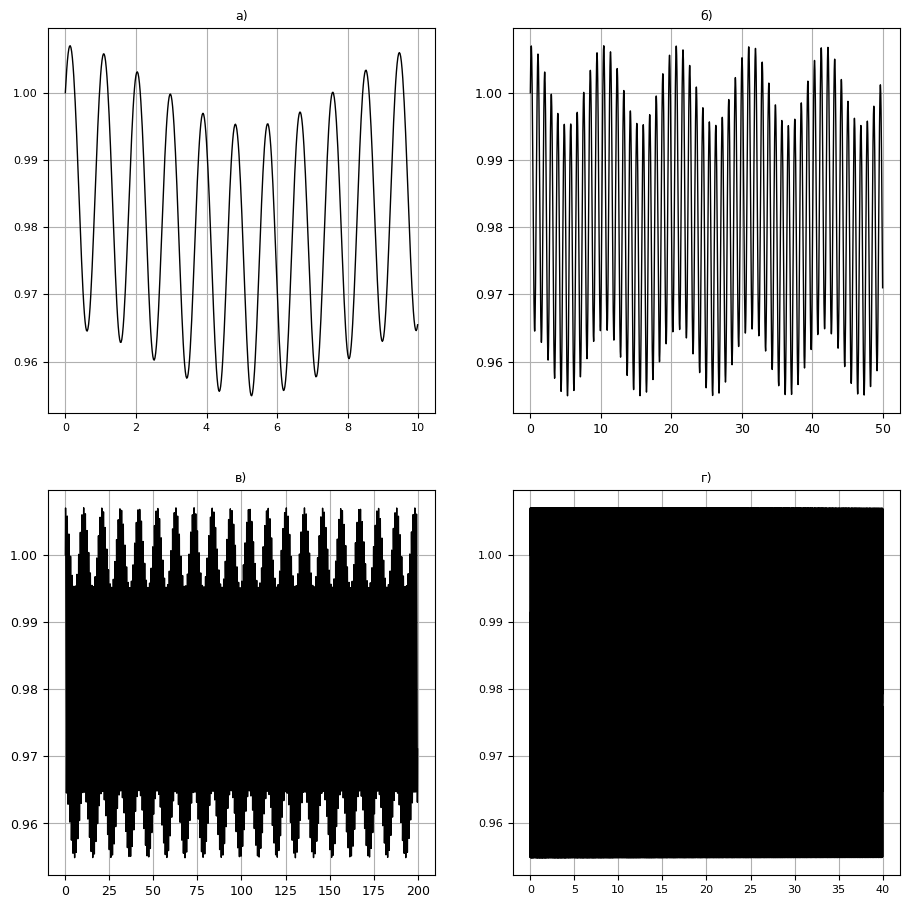

In [6]:
# Ячейка № 6

# визуализация зависимостей:
# |R(t)|, x(t), y(t), z(t)

fig = plt.figure(figsize=(11, 11))
# визуализация зависимости |R(t)|
# на временном интервале[0, 10]
ax = fig.add_subplot(2, 2, 1)
ax.plot(Solv.t[0:N1_fin], mod_R[0:N1_fin], "-k", lw=1)
ax.grid(True)
ax.set_title("а)", fontsize=9)
ax.tick_params(labelsize=8)

# визуализация зависимости |R(t)|
# на временном интервале[0, 50]
ax = fig.add_subplot(2, 2, 2)
ax.plot(Solv.t[0:N2_fin], mod_R[0:N2_fin], "-k", lw=1)
ax.grid(True)
ax.set_title("б)", fontsize=9)

ax.tick_params(labelsize=9)

# визуализация зависимости |R(t)|
# на временном интервале[0, 200]
ax = fig.add_subplot(2, 2, 3)
ax.plot(Solv.t[0:N3_fin], mod_R[0:N3_fin], "-k", lw=1)
ax.grid(True)
ax.set_title("в)", fontsize=9)
ax.tick_params(labelsize=9)

# визуализация зависимости |R(t)|
# на временном интервале[0, 40000]
ax = fig.add_subplot(2, 2, 4)
ax.plot(Solv.t / 10**3, mod_R, "-k", lw=1)
ax.grid(True)
ax.set_title("г)", fontsize=9)

ax.tick_params(labelsize=8)

plt.show()

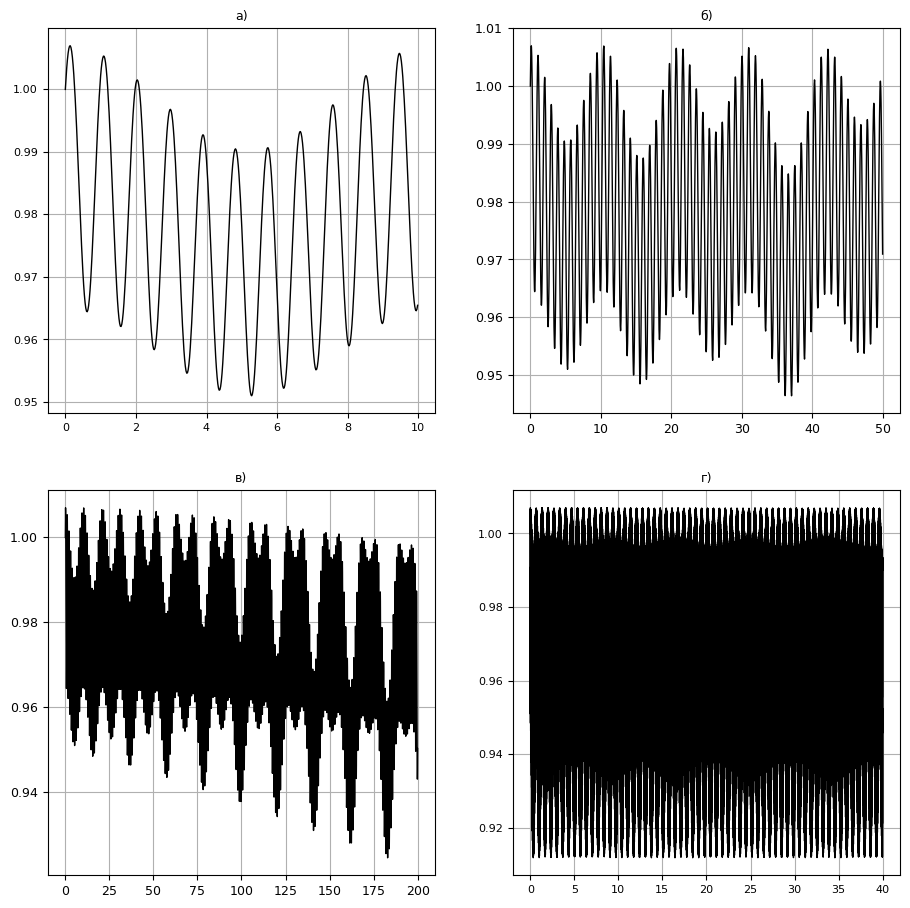

In [7]:
# Ячейка № 7

# визуализация зависимости
# модуля проекции радиуса-вектора
# на плоскость XOY от времени
# на временном интервале[0,10]

# вычисление мгновенных значений
# модуля проекции радиуса-вектора
# электрического заряда
mod_Rxy = np.sqrt(Solv.y[0, :] ** 2 + Solv.y[2, :] ** 2)

fig = plt.figure(figsize=(11, 11))
# визуализация  мгновенных значений
# модуля проекции радиуса-вектора
# электрического заряда
# на временном интервале [0, 10]
ax = fig.add_subplot(2, 2, 1)
ax.plot(Solv.t[0:N1_fin], mod_Rxy[0:N1_fin], "-k", lw=1)
ax.grid(True)
ax.set_title("а)", fontsize=9)
ax.tick_params(labelsize=8)

# визуализация  мгновенных значений
# модуля проекции радиуса-вектора
# электрического заряда
# на временном интервале [0, 50]
ax = fig.add_subplot(2, 2, 2)
ax.plot(Solv.t[0:N2_fin], mod_Rxy[0:N2_fin], "-k", lw=1)
ax.grid(True)
ax.set_title("б)", fontsize=9)

ax.tick_params(labelsize=9)

# визуализация  мгновенных значений
# модуля проекции радиуса-вектора
# электрического заряда
# на временном интервале [0, 200]
ax = fig.add_subplot(2, 2, 3)
ax.plot(Solv.t[0:N3_fin], mod_Rxy[0:N3_fin], "-k", lw=1)
ax.grid(True)
ax.set_title("в)", fontsize=9)
ax.tick_params(labelsize=9)

# визуализация  мгновенных значений
# модуля проекции радиуса-вектора
# электрического заряда
# на временном интервале [0, 40000]
ax = fig.add_subplot(2, 2, 4)
ax.plot(Solv.t / 10**3, mod_Rxy, "-k", lw=1)
ax.grid(True)
ax.set_title("г)", fontsize=9)

ax.tick_params(labelsize=8)

plt.show()

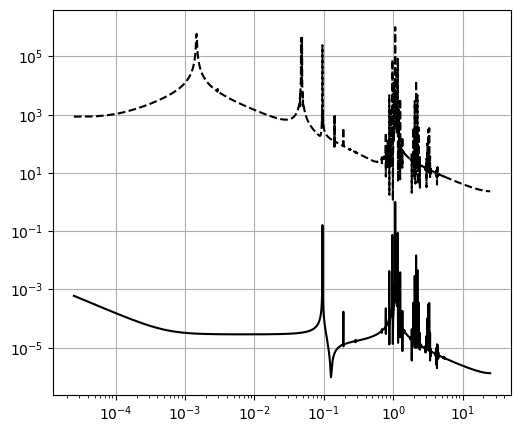

In [8]:
# Ячейка № 8

# визуализация спектров
# мгновенных значений
# зависимостей модулей
# радиуса-вектора электрического заряда
# и его проекции на плоскость XOY,
# в размещенных массивах mod_R, mod_Rxy

# вычисление частот спектральных гармоник
xf = fftfreq(N, dt)[1 : round(N / 2)]

# вычисление ДПФ массива mod_R
sp_R = fft(mod_R)

# вычисление модуля коэффициента ДПФ
# гармоники с максимальной амплитудой
sp_max_R = np.max(np.abs(sp_R[1:N]))

# нормировка коэффициентов ДПФ
sp_R = sp_R / sp_max_R

# вычисление ДПФ массива mod_Rxy
sp_Rxy = fft(mod_Rxy)[1:N]

# вычисление модуля коэффициента ДПФ
# гармоники с максимальной амплитудой
sp_max_Rxy = np.max(np.abs(sp_Rxy[1:N]))

# нормировка коэффициентов ДПФ
sp_Rxy = sp_Rxy / sp_max_Rxy

# визуализация спектров
# зависимостей mod_R, mod_Rxy
fig = plt.figure(figsize=(13, 11))
ax = fig.add_subplot(2, 2, 1)
plt.loglog(xf[0 : len(xf) - 1], np.abs(sp_R[1 : len(xf)]), "-k")

plt.loglog(xf[0 : len(xf) - 1], 10**6 * np.abs(sp_Rxy[1 : len(xf)]), "--k")
plt.grid(True)


plt.show()

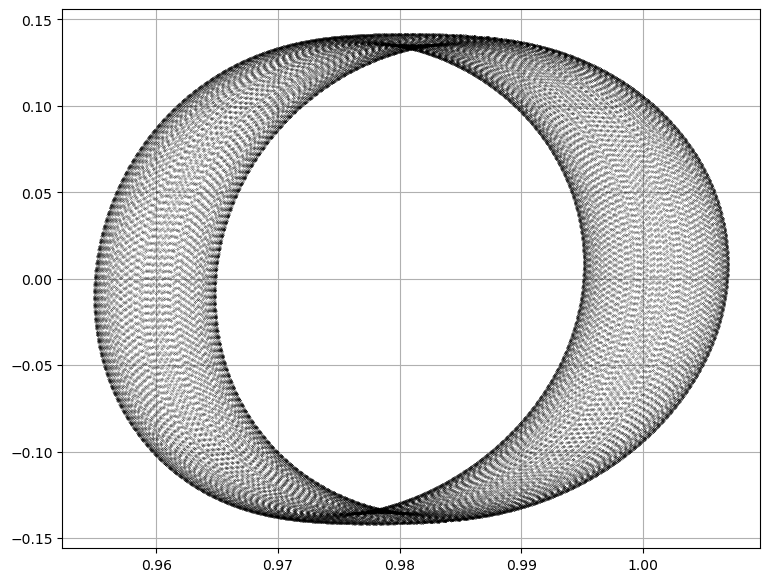

In [9]:
# Ячейка № 9

# визуализация фазовой траектории
# модуля радиуса-вектора

# вычисление мгновенных значений
# производной зависимости |R(t)|
diff_mod_R = np.diff(mod_R) / dt

# визуализация фазовой траектории
# зависимости |R(t)|
# на временном интервале [0, t[round N / 20 - 1]
plt.figure(figsize=(9, 7))
plt.plot(
    mod_R[1 : round(N / 20)], diff_mod_R[0 : round(N / 20) - 1], ".k", markersize=0.2
)
plt.grid(True)

plt.show()

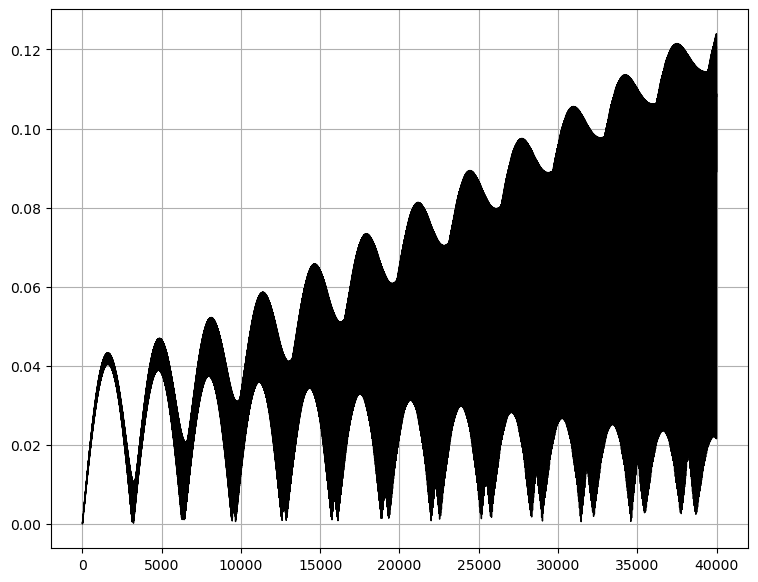

In [ ]:
# Ячейка № 10

# вычисление и визуализация расстояния
# между траектории движения заряда,
# близкими в момент времени t = 0

# задание нового значения абсциссы начальной точки
x0 = 1.0 + 10**-4

# вычисление численного решения СДУ (6.87)
# с измененными начальными условиями
Solv2 = solve_ivp(Force, [0, Tmax], [x0, vx0, y0, vy0, z0, vz0], max_step=dt)

# вычисление мгновенных значений координат
# разностей координат траекторий движения
# электрического заряда, близких в момент времени t = 0
dx = Solv.y[0, :] - Solv2.y[0, :]
dy = Solv.y[2, :] - Solv2.y[2, :]
dz = Solv.y[4, :] - Solv2.y[4, :]

# задание начального и конечного значений
# номеров элементов массивов,
# используемых для визуализации
# расстояния между траекториями,
# близкими в начальный момент времени
N1 = 0  # round(N - N / 200)
N2 = N - 1

# визуализация мгновенных значений
# между траектории движения
# электрического заряда,
# близкими в момент времени t = 0
plt.figure(figsize=(9, 7))
plt.plot(
    Solv.t[N1:N2], np.sqrt(dx[N1:N2] ** 2 + dy[N1:N2] ** 2 + dz[N1:N2] ** 2), "-k", lw=1
)
plt.grid(True)

plt.show()